# pathmap使用


{'topic': '猫咪', 'poem': '## 《猫咪》\n\n尾巴在风里打捞云朵\n它翻身时\n坠落半抹月光\n\n光影爬上绒毛的阶梯\n肉垫压住地板\n潜伏的惊雷\n\n在窗口\n它用肋骨丈量\n风的密度\n骨节里梅花\n一朵接一朵炸开\n\n忽然摁住影子\n像摁住\n半部舞蹈', 'content_type': '诗'}
{'topic': '猫咪', 'joke': '# 一个关于猫咪的笑话\n\n有一只猫走进了一家宠物店，对店里的鹦鹉说：“嘿，你知道为什么我们猫咪从来不发明什么东西吗？”\n\n鹦鹉好奇地问：“为什么啊？”\n\n猫淡定地回答：“因为我们有猫（毛）就够了！你们人类总说‘科技改变生活’，可我们有猫就够了——晒太阳、抓沙发、睡大觉，这还不够‘高科技’吗？”\n\n鹦鹉听完，愣了三秒：“那你们怎么解释‘猫抓板’这东西？”\n\n猫翻了个白眼：“那是人类发明的，我们只是配合演出而已。”\n\n（笑话结束，喵～）', 'content_type': '笑话'}


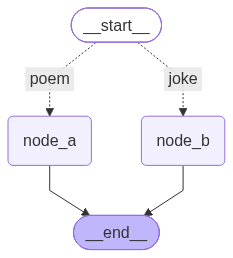

In [1]:
from typing import TypedDict, Literal

from IPython.display import display
from dotenv import load_dotenv
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import StateGraph, START, END

load_dotenv(override=True)

# 获取模型
model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={"thinking": {"type": "disabled"}}
)


# 1、定义状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    content_type: str


# 2、定义节点
def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke(f"请写一个关于{state["topic"]}的诗").content
    return {
        "poem": poem
    }


def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke(f"请写一个关于{state["topic"]}的笑话").content
    return {
        "joke": joke
    }


# 定义路由
# 此时返回为内容，无法进行路由自动映射，需要通过pathmap
def route(state: OverAllState) -> Literal["poem", "joke"]:
    if "诗" in state["content_type"]:
        return "poem"
    else:
        return "joke"


# 3、构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node(node_a)
builder.add_node(node_b)
# builder.add_edge(START, "node_a")
# builder.add_edge(START, "node_b")
# path_map key是路由的返回值，value：对应的真实节点名称
builder.add_conditional_edges(START, route, path_map={
    "poem": "node_a",
    "joke": "node_b"
})
builder.add_edge("node_b", END)
builder.add_edge("node_a", END)

graph = builder.compile()
poem_res = graph.invoke({"topic": "猫咪", "content_type": "诗"})
print(poem_res)

joke_res = graph.invoke({"topic": "猫咪", "content_type": "笑话"})
print(joke_res)

display(graph)